## Assignment 3: Pattern Mining and Recommender Systems

### Aryan Moradi, A1779263, Version 02

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [46]:
train_path = 'Groceries data train.csv'
test_path  = 'Groceries data test.csv'
train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)

# Exploratory Data Analysis (EDA)

In [47]:
train_df = train_df.rename(columns={"User_id": "user_id"})

In [48]:
for df in (train_df, test_df):
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [49]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train shape: (19382, 7)
Test  shape: (19383, 7)

Columns: ['user_id', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']

Missing values (train):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64

Missing values (test):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


We first fix the inconsistency of the column name for train and test datasets. The we see that both datasets are very similar in size, 19.4k rows and 7 columns. No missing values were detected, so no immediate cleaning is required. We also parse the value of the Date column to appropriate type to be able work with it easily later on. Each row appears to represent a single item purchased by a user on a specific date so potentially we might need to consolidate all the user specific purchases on the specific date together in one row if need be.

In [74]:
train_daily = train_df.groupby('Date').size().reset_index(name='Transactions')
test_daily = test_df.groupby('Date').size().reset_index(name='Transactions')


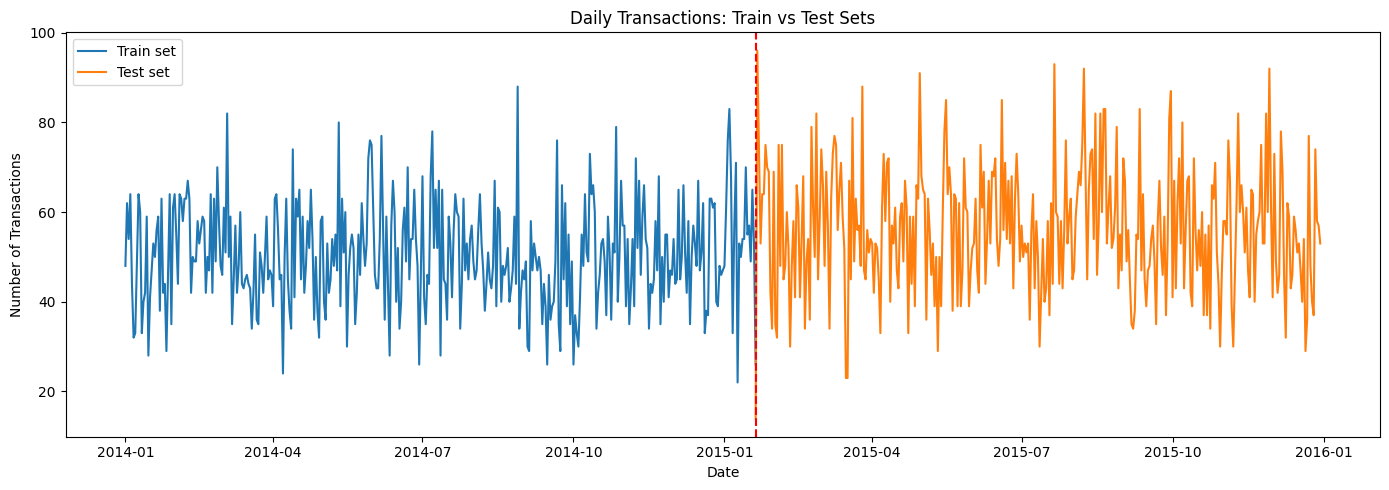

In [78]:
plt.figure(figsize=(14, 5))
plt.plot(train_daily['Date'], train_daily['Transactions'], label='Train set')
plt.plot(test_daily['Date'], test_daily['Transactions'], label='Test set')

plt.title('Daily Transactions: Train vs Test Sets')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.axvline(x=test_daily['Date'].min(), color='r', linestyle='--', label='Train/Test Split')
plt.tight_layout()
plt.show()

We then generate the joint transaction vs date plot of train and test datasets to have general idea of how everything looks throughout the timeline. Sales volume is relatively stable week‑to‑week with mild seasonality. The 2014 series shows two noticeable dips around late April and late December, likely holiday effects. 2015 follows a similar baseline, which could mean the two datasets are comparable for modelling. 

In [80]:
top20_train = train_df["itemDescription"].value_counts().head(20)
top20_test  = test_df["itemDescription"].value_counts().head(20)

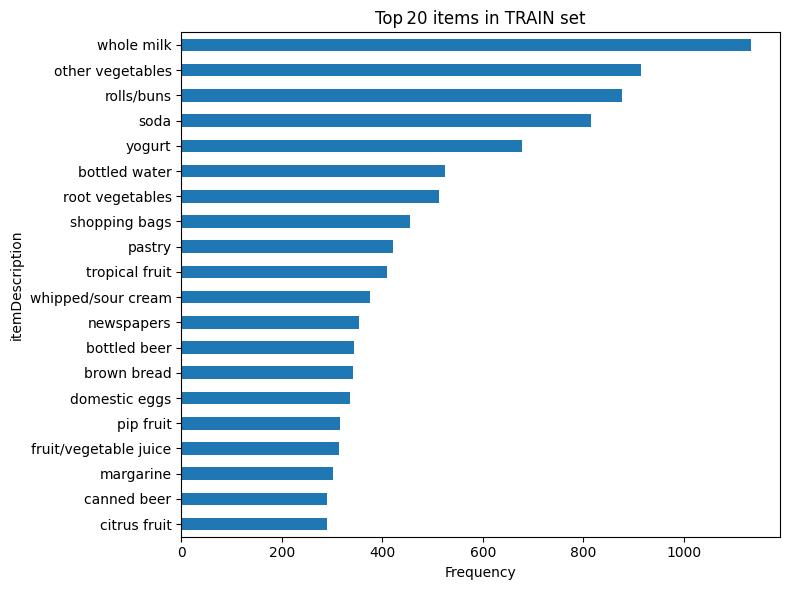

In [82]:
fig, ax = plt.subplots(figsize=(8,6))
top20_train[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 items in TRAIN set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

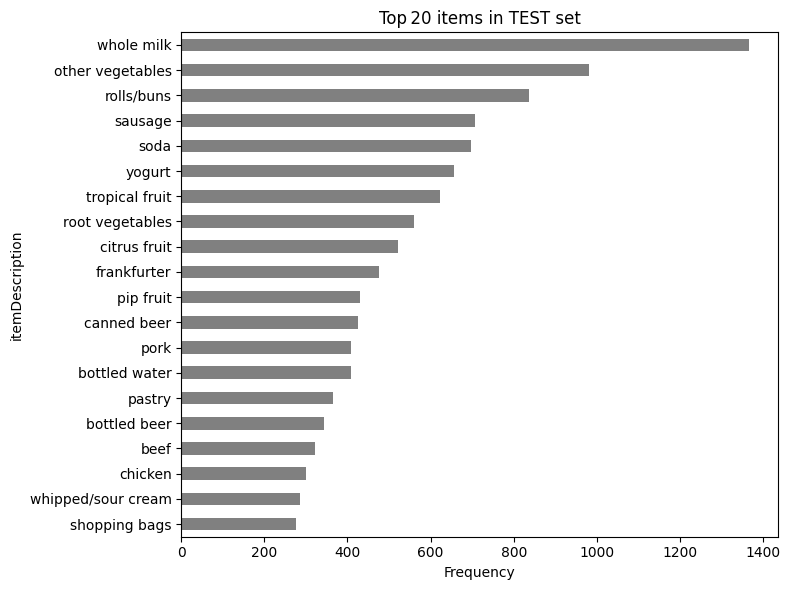

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
top20_test[::-1].plot(kind="barh", ax=ax, color="grey")
ax.set_title("Top 20 items in TEST set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

We then proceed to analyzes and visualizes the purchasing patterns in a grocery store dataset across the entire date time. The visualization shows horizontal bar charts of the top 20 most frequently purchased items in both datasets. The findings indicate that basic grocery staples dominate purchases, with "whole milk" being the most purchased item in both years, followed by "other vegetables" and "rolls/buns". The data exhibits a classic long-tail distribution, where a small number of products account for a large proportion of total sales which is a common phenomenon in retail. This pattern is valuable for inventory management and store layout planning, as it helps identify which products should be given prime shelf space and maintained in higher stock levels. 

In [90]:
n_users_train = train_df["user_id"].nunique()
n_users_test  = test_df["user_id"].nunique()
print(f"Unique users in 2014 (train): {n_users_train:,}")
print(f"Unique users in 2015 (test):  {n_users_test:,}")

Unique users in 2014 (train): 3,493
Unique users in 2015 (test):  3,231


In [87]:
items_per_user = train_df.groupby("user_id")["itemDescription"].count()

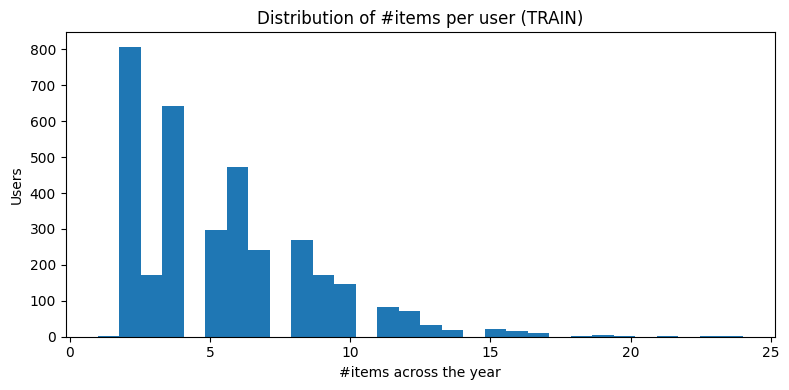

In [88]:
plt.figure(figsize=(8,4))
plt.hist(items_per_user, bins=30)
plt.title("Distribution of #items per user (TRAIN)")
plt.xlabel("#items across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We find out that there are 3,493 unique users in the training set and 3,231 unique users in the test set. Next, we generate a histogram barplot to see how many distinct items each shoppers grabbed over the whole training year. The result is sharply right-skewed as expected. Around 800 users only shopped 1-3 items all year, whereas around 650 bought 3-4, and this count continues to thin out after 10-20 items which only a fraction of users past 15 items. In other word, the dataset is dominated by light buyers with a long tail of heavy shoppers as we found previously. This will come in handy when we weight similarities such as user-user CF could over-fit those big baskets unless we normalize for basket size or down-weight high-frequency users. 

In [91]:
dow_map = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train_dow = train_df["day_of_week"].value_counts().sort_index()
test_dow  = test_df["day_of_week"].value_counts().sort_index()

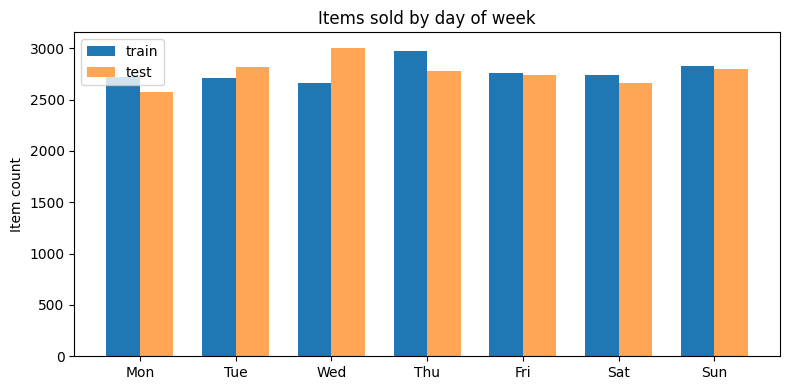

In [93]:
x = np.arange(7)
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, train_dow.values, width, label="train")
ax.bar(x + width/2, test_dow.values,  width, label="test", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(dow_map)
ax.set_title("Items sold by day of week")
ax.set_ylabel("Item count")
ax.legend()
plt.tight_layout()
plt.show()

We try to visualize a bar plot to have a better sense of the number of items bought for each day of the week. The observed pattern is pleasantly flat, which means each day hovers around 2.6-3 k items, with Thursday topping 3 k in the 2014 slice and Wednesday doing the same in 2015. Weekends don’t spike much, and Mondays drag only a touch, so demand is fairly even across the week. This is relatively good since it means we can’t blame any accuracy gaps on a weekday mismatch between the two splits. 

In [99]:
train_baskets = (
    train_df
      .groupby(["user_id", "Date"])
      .size()
      .reset_index(name="items_in_basket")
)

In [101]:
baskets_per_user = train_baskets.groupby("user_id").size()

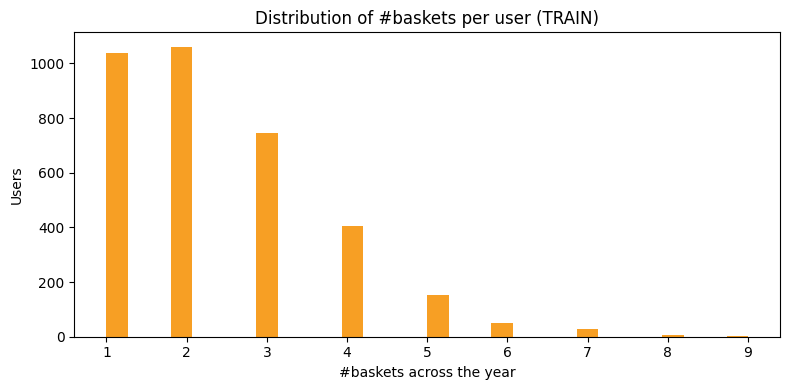

In [102]:
plt.figure(figsize=(8,4))
plt.hist(baskets_per_user, bins=30, color="#F79F24")
plt.title("Distribution of #baskets per user (TRAIN)")
plt.xlabel("#baskets across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

We move on to determining some important features of the dataset we are dealing with. We know that each row of the dataset represents a singular item purchased by a specific user at a specific date, where a given user can buy the same item at multiple occasions hence why in order to have a better understanding of the baskets bought per user, we need to consolidate appropriate rows to generate the basket per transaction dataset. Once we do that, we generate a barplot to help investigate the number of baskets per user throughout the training dataset. We find out that most shoppers are truly occasional. Over half show up just once or twice all year, a further third land in the 3-4-visit range, and only a fraction pushes past five baskets. This is consistent with our findings earlier. That light-touch profile means any user-user CF model will be starved for co-occurrence data on the vast majority of customers. Hence why we might need either strong smoothing, hybrid techniques, or to lean harder on item-based signals for coverage. On the marketing side, this means the shop owners should try to get the one-time shoppers to come back for a second or third visit, instead of putting all your effort into the few people who already shop very often. 

In [95]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['itemDescription'].unique()
print("Number of unique users:", len(unique_users))
print("Number of unique items:", len(unique_items))

Number of unique users: 3493
Number of unique items: 167


In [97]:
user_item_matrix = train_df.pivot_table(
    index='user_id',
    columns='itemDescription',
    values='Date',
    aggfunc='count',
    fill_value=0
)
user_item_matrix

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
user_id,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [57]:
user_similarity = cosine_similarity(user_item_matrix)

In [58]:
user_idx = user_item_matrix.index.get_loc(2351)
user_idx

1170

In [59]:
similar_users =user_similarity[1170].argsort()[::-1][1:8]
similar_users

array([2835, 2548, 1502, 2938, 1535, 1003, 2371])

In [60]:
neighbours_idx = np.argsort(-user_similarity[1170])[1:8]
neighbours_idx

array([2835, 2548, 1502, 2938, 1003,  168, 1535])

In [61]:
# Indices to map quickly between user IDs and matrix rows
user_index = {u: i for i, u in enumerate(user_item_matrix.index)}
item_index = {i: j for j, i in enumerate(user_item_matrix.columns)}

In [62]:
def get_user_recommendations(user_id, k_neighbours=50, n_recommendations=10):
    """
    Return `n_recommendations` item IDs the target `user_id` is most likely to buy next,
    using user-user cosine similarity on log-scaled purchase counts.
    """
    if user_id not in user_index:
        raise ValueError(f"user_id {user_id} not found in training data")

    u_idx = user_index[user_id]

    # top-k neighbours (skip self at position 0)
    neighbours_idx = np.argsort(-user_similarity[u_idx])[1:k_neighbours + 1]
    neighbour_sims = user_similarity[u_idx, neighbours_idx]

    # Weighted sum of neighbours’ frequencies for each item
    neighbour_freqs = user_item_matrix.values[neighbours_idx]
    scores = neighbour_sims @ neighbour_freqs    # shape = (num_items,)

    # Mask items the user already bought at least once
    bought_mask = user_item_matrix.values[u_idx] > 0
    scores[bought_mask] = -np.inf

    # Top-N recommendations
    top_items_idx = np.argsort(-scores)[:n_recommendations]
    recommended_items = user_item_matrix.columns[top_items_idx].tolist()

    return recommended_items

In [63]:
print(get_user_recommendations(user_id=2351, k_neighbours=50, n_recommendations=5))

['whole milk', 'root vegetables', 'other vegetables', 'newspapers', 'rolls/buns']


In [64]:
def get_user_based_recommendations(user_id, n_recommendations=5):
    n_users = len(user_item_matrix.index)
    user_similarity = np.zeros((n_users, n_users))
    for i in range(n_users):
        for j in range(n_users):
            user_similarity[i,j] = similarity(user_item_matrix.iloc[i], user_item_matrix.iloc[j])
    
    user_idx = user_item_matrix.index.get_loc(user_id)
    
    similar_users = user_similarity[user_idx].argsort()[::-1][1:6]
    
    similar_user_purchases = user_item_matrix.iloc[similar_users].mean(axis=0)
    
    user_purchases = user_item_matrix.iloc[user_idx]
    similar_user_purchases[user_purchases > 0] = -1
    
    recommendations = similar_user_purchases.nlargest(n_recommendations).index
    
    return recommendations

In [65]:
def get_item_based_recommendations(user_id, n_recommendations=5):

    n_items = len(user_item_matrix.columns)
    item_similarity = np.zeros((n_items, n_items))
    for i in range(n_items):
        for j in range(n_items):
            item_similarity[i,j] = similarity(user_item_matrix.T.iloc[i], user_item_matrix.T.iloc[j])
    
    user_idx = user_item_matrix.index.get_loc(user_id)
    user_purchases = user_item_matrix.iloc[user_idx].values
    
    weighted_sums = item_similarity.dot(user_purchases)
    
    weighted_sums[user_purchases.nonzero()] = -1
    
    top_items_idx = weighted_sums.argsort()[-n_recommendations:][::-1]
    recommendations = user_item_matrix.columns[top_items_idx]
    
    return recommendations

In [66]:
user_id = 2351

item_based_recommendations = get_item_based_recommendations(user_id)
user_based_recommendations = get_user_based_recommendations(user_id)

print("Item-based recomm  endations:", item_based_recommendations)
print("User-based recommendations:", user_based_recommendations)

NameError: name 'similarity' is not defined